In [ ]:
!pip install segmentation-models-pytorch torch torchvision nibabel tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


In [ ]:
import os, json, random, time
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Import xong!")
print(f"   Device : {DEVICE}")
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {vram_gb:.1f} GB")
print(f"   PyTorch: {torch.__version__}")
print(f"   SMP    : {smp.__version__}")

✅ Import xong!
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 14.6 GB
   PyTorch: 2.10.0+cu128
   SMP    : 0.5.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
DRIVE_ROOT     = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
IMAGES_2D_DIR  = f"{DRIVE_ROOT}/data/processed/images"
MASKS_2D_DIR   = f"{DRIVE_ROOT}/data/processed/masks"
METADATA_PATH  = f"{DRIVE_ROOT}/data/processed/metadata.json"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints_baseline"
LOG_DIR        = f"{DRIVE_ROOT}/logs_baseline"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

CURRENT_TASK  = 4
IGNORE_INDEX  = 255

TRAIN_CFG = {
    "batch_size"       : 16,
    "lr"               : 3e-4,
    "n_epochs"         : 15,
    "save_every"       : 10,
    "val_ratio"        : 0.2,
    "num_workers"      : 2,
    "loss_alpha"       : 0.5,
    "encoder"          : "resnet34",
    "pretrained"       : "imagenet",
    "num_classes"      : 14,
    "seed"             : 42,
    "use_amp"          : True,
    "label_smoothing"  : 0.0,
}

random.seed(TRAIN_CFG["seed"])
np.random.seed(TRAIN_CFG["seed"])
torch.manual_seed(TRAIN_CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAIN_CFG["seed"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print("✅ Cấu hình:")
print(f"   Task hiện tại: {CURRENT_TASK}")
for k, v in TRAIN_CFG.items():
    print(f"   {k:15s}: {v}")

✅ Cấu hình:
   Task hiện tại: 4
   batch_size     : 16
   lr             : 0.0003
   n_epochs       : 15
   save_every     : 10
   val_ratio      : 0.2
   num_workers    : 2
   loss_alpha     : 0.5
   encoder        : resnet34
   pretrained     : imagenet
   num_classes    : 14
   seed           : 42
   use_amp        : True
   label_smoothing: 0.0


## 🗂️ Step 2 — Task Definitions & Helper Functions

In [ ]:
# ============================================================
# Định nghĩa 4 Task — Nhóm từ lớn → nhỏ
# Giữ nguyên label gốc (1-13), KHÔNG đánh lại từ 1
# → Dùng chung 1 model 14 channel cho tất cả task
# ============================================================
TASK_ORGANS = {
    1: [6, 7],           # Liver(6), Stomach(7)             — cơ quan LỚN nhất
    2: [1, 2, 3, 8],     # R.Kidney(2), L.Kidney(3),
                         # Spleen(1), Aorta(8)             — cơ quan TRUNG BÌNH
    3: [4, 9, 10, 11],   # Gallbladder(4), IVC(9),
                         # Portal Vein(10), Pancreas(11)    — cơ quan NHỎ
    4: [5, 12, 13],      # Esophagus(5), R.Adrenal(12),
                         # L.Adrenal(13)                    — cơ quan RẤT NHỎ
}

ORGAN_NAMES = {
    0:  "Background",
    1:  "Spleen (Lách)",
    2:  "Right Kidney (Thận P)",
    3:  "Left Kidney (Thận T)",
    4:  "Gallbladder (Túi mật)",
    5:  "Esophagus (Thực quản)",
    6:  "Liver (Gan)",
    7:  "Stomach (Dạ dày)",
    8:  "Aorta (ĐM chủ)",
    9:  "IVC (TM chủ dưới)",
    10: "Portal Vein (TM cửa)",
    11: "Pancreas (Tụy)",
    12: "Right Adrenal (TTT P)",
    13: "Left Adrenal (TTT T)",
}

# Các organ đã học tính đến hết task k (dùng cho KD ở Phase 3)
ALL_PAST_ORGANS = {
    1: [6, 7],
    2: [6, 7, 1, 2, 3, 8],
    3: [6, 7, 1, 2, 3, 8, 4, 9, 10, 11],
    4: [6, 7, 1, 2, 3, 8, 4, 9, 10, 11, 5, 12, 13],
}

print(f"✅ Task definitions:")
for task_id, organs in TASK_ORGANS.items():
    organ_names = [ORGAN_NAMES[o] for o in organs]
    marker = " ← CURRENT" if task_id == CURRENT_TASK else ""
    print(f"   Task {task_id}: {organ_names}{marker}")

✅ Task definitions:
   Task 1: ['Liver (Gan)', 'Stomach (Dạ dày)']
   Task 2: ['Spleen (Lách)', 'Right Kidney (Thận P)', 'Left Kidney (Thận T)', 'Aorta (ĐM chủ)']
   Task 3: ['Gallbladder (Túi mật)', 'IVC (TM chủ dưới)', 'Portal Vein (TM cửa)', 'Pancreas (Tụy)']
   Task 4: ['Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)'] ← CURRENT


In [ ]:
# ============================================================
# Helper Functions — Dùng xuyên suốt dự án
# ============================================================

def remap_mask_for_task(mask_npy, task_id, ignore_index=255):
    """
    Remap mask gốc cho task huấn luyện hiện tại.

    Quy tắc:
      - Background (0)           → 0     (luôn là background)
      - Organ thuộc task_id      → giữ label gốc (ví dụ 1, 6)
      - Organ KHÔNG thuộc task   → ignore_index (255)
                                   → bị BỎ QUA hoàn toàn trong loss
                                   → tốt hơn là gán về 0 (tránh background shift)

    Args:
        mask_npy     : numpy array (H, W), uint8, giá trị 0-13
        task_id      : int, task đang train (1, 2, 3, hoặc 4)
        ignore_index : int, giá trị dùng để đánh dấu bỏ qua (default 255)
    Returns:
        numpy array (H, W), uint8, giá trị {0, organ_ids, 255}
    """
    task_organs = TASK_ORGANS[task_id]

    # Bắt đầu với tất cả pixel = ignore_index (bỏ qua)
    new_mask = np.full_like(mask_npy, fill_value=ignore_index, dtype=np.uint8)

    # Background luôn là 0
    new_mask[mask_npy == 0] = 0

    # Organ của task hiện tại → giữ nguyên label
    for organ_id in task_organs:
        new_mask[mask_npy == organ_id] = organ_id

    return new_mask


def get_slices_for_task(metadata, task_id):
    """
    Lọc slice có ÍT NHẤT 1 organ thuộc task_id.
    Slice không có organ nào của task → bỏ qua (sẽ toàn là 0+255).
    """
    task_organs = set(TASK_ORGANS[task_id])
    return [r for r in metadata if task_organs & set(r["organs_present"])]


def log_vram(label=""):
    """In tình trạng VRAM hiện tại — cảnh báo nếu > 85%."""
    if not torch.cuda.is_available():
        return
    used  = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    pct   = used / total * 100
    tag   = "⚠️ WARNING" if pct > 85 else "✅"
    msg   = f"   {tag} VRAM {label}: {used:.2f}/{total:.1f} GB ({pct:.0f}%)"
    print(msg)


# --- Test remap_mask_for_task ---
print("🧪 Test remap_mask_for_task:")
dummy_mask = np.array([[0, 1, 3, 6, 7, 8, 9, 12, 13]], dtype=np.uint8)
print(f"   Mask gốc      : {dummy_mask[0]}")
for tid in [1, 2, 3, 4]:
    remapped = remap_mask_for_task(dummy_mask, tid)[0]
    kept = [v for v in remapped if v not in [0, 255]]
    print(f"   Task {tid} remap  : {remapped}  → organ giữ lại: {kept}")

🧪 Test remap_mask_for_task:
   Mask gốc      : [ 0  1  3  6  7  8  9 12 13]
   Task 1 remap  : [  0 255 255   6   7 255 255 255 255]  → organ giữ lại: [np.uint8(6), np.uint8(7)]
   Task 2 remap  : [  0   1   3 255 255   8 255 255 255]  → organ giữ lại: [np.uint8(1), np.uint8(3), np.uint8(8)]
   Task 3 remap  : [  0 255 255 255 255 255   9 255 255]  → organ giữ lại: [np.uint8(9)]
   Task 4 remap  : [  0 255 255 255 255 255 255  12  13]  → organ giữ lại: [np.uint8(12), np.uint8(13)]


## ✂️ Step 3 — Train/Val Split (theo Volume)

In [ ]:
# ============================================================
# Train/Val Split THEO VOLUME — CỐ ĐỊNH GIỮA CÁC TASK
# ============================================================
# Split được lưu vào file JSON sau Task 1.
# Các Task sau load lại đúng split đó → tránh data leakage.
# ============================================================

with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

print(f"📂 Tổng số slices trong metadata : {len(metadata)}")

all_vol_ids = sorted(set(r["volume_id"] for r in metadata))
print(f"   Tổng số volumes               : {len(all_vol_ids)}")

# --- Load split đã lưu (Task 2+) hoặc tạo mới (Task 1) ---
SPLIT_PATH = f"{LOG_DIR}/volume_split.json"

if os.path.exists(SPLIT_PATH):
    # ✅ Load lại split cũ — KHÔNG shuffle lại
    with open(SPLIT_PATH, 'r') as f:
        split_data = json.load(f)
    train_vol_ids = set(split_data["train"])
    val_vol_ids   = set(split_data["val"])
    print(f"\n✅ Loaded split từ file: {SPLIT_PATH}")
    print(f"   Train volumes ({len(train_vol_ids)}): {sorted(train_vol_ids)}")
    print(f"   Val   volumes ({len(val_vol_ids)}) : {sorted(val_vol_ids)}")

else:
    # 🆕 Task 1: tạo split lần đầu rồi lưu lại
    random.shuffle(all_vol_ids)
    n_val         = max(1, int(len(all_vol_ids) * TRAIN_CFG["val_ratio"]))
    val_vol_ids   = set(all_vol_ids[:n_val])
    train_vol_ids = set(all_vol_ids[n_val:])

    # Lưu split để các Task sau dùng lại
    with open(SPLIT_PATH, 'w') as f:
        json.dump({
            "train": sorted(train_vol_ids),
            "val"  : sorted(val_vol_ids)
        }, f, indent=2)

    print(f"\n🆕 Tạo split mới và lưu vào: {SPLIT_PATH}")
    print(f"   Train volumes ({len(train_vol_ids)}): {sorted(train_vol_ids)}")
    print(f"   Val   volumes ({len(val_vol_ids)}) : {sorted(val_vol_ids)}")

# --- Lọc metadata theo task VÀ split ---
task_slices   = get_slices_for_task(metadata, CURRENT_TASK)
train_records = [r for r in task_slices if r["volume_id"] in train_vol_ids]
val_records   = [r for r in task_slices if r["volume_id"] in val_vol_ids]

print(f"\n📊 Kết quả lọc cho Task {CURRENT_TASK} (organs {TASK_ORGANS[CURRENT_TASK]}):")
print(f"   Slices có organ task {CURRENT_TASK}  : {len(task_slices):,}")
print(f"   → Train slices              : {len(train_records):,}")
print(f"   → Val slices                : {len(val_records):,}")

📂 Tổng số slices trong metadata : 1933
   Tổng số volumes               : 30

✅ Loaded split từ file: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/volume_split.json
   Train volumes (24): ['img0001', 'img0002', 'img0003', 'img0004', 'img0005', 'img0006', 'img0008', 'img0009', 'img0010', 'img0022', 'img0023', 'img0024', 'img0026', 'img0027', 'img0028', 'img0029', 'img0031', 'img0032', 'img0034', 'img0035', 'img0036', 'img0038', 'img0039', 'img0040']
   Val   volumes (6) : ['img0007', 'img0021', 'img0025', 'img0030', 'img0033', 'img0037']

📊 Kết quả lọc cho Task 4 (organs [5, 12, 13]):
   Slices có organ task 4  : 1,011
   → Train slices              : 814
   → Val slices                : 197


## 🗃️ Step 4 — BTCVDataset Class

In [ ]:
# ============================================================
# BTCVDataset — Trái tim của pipeline dữ liệu
# Augmentation: chỉ spatial nhẹ (flip + rot90)
# ============================================================

class BTCVDataset(Dataset):
    """
    Dataset load 2D axial slices .npy của BTCV.

    Modes:
      task_id = None  → Baseline mode: load full mask (0-13)
      task_id = 1,2,3,4 → CIL mode: remap mask cho task hiện tại
    """

    def __init__(self, records, images_dir, masks_dir,
                 task_id=None, augment=False, ignore_index=255):
        """
        Args:
            records      : list[dict] từ metadata.json
            images_dir   : thư mục chứa CT .npy files
            masks_dir    : thư mục chứa mask .npy files
            task_id      : int hoặc None
            augment      : bool, spatial augmentation (flip, rot90)
            ignore_index : giá trị bỏ qua trong loss
        """
        self.records        = records
        self.images_dir     = images_dir
        self.masks_dir      = masks_dir
        self.task_id        = task_id
        self.augment        = augment
        self.ignore_index   = ignore_index
        self._printed_shape = False

        mode_str = "TRAIN+aug" if augment else "EVAL"
        print(f"  📦 BTCVDataset [{mode_str}]: "
              f"{len(records)} slices, task_id={task_id}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        ct_npy   = np.load(os.path.join(self.images_dir, rec["filename"]))
        mask_npy = np.load(os.path.join(self.masks_dir,  rec["filename"]))

        if self.task_id is not None:
            mask_npy = remap_mask_for_task(mask_npy, self.task_id,
                                           self.ignore_index)

        if self.augment:
            ct_npy, mask_npy = self._augment(ct_npy, mask_npy)

        # Debug shape — chỉ in lần đầu
        if not self._printed_shape:
            print(f"    [BTCVDataset] first sample: ct={ct_npy.shape}, "
                  f"mask={mask_npy.shape}, dtype_ct={ct_npy.dtype}")
            self._printed_shape = True

        ct_tensor   = torch.from_numpy(ct_npy.copy()).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask_npy.astype(np.int64))

        return ct_tensor, mask_tensor

    def _augment(self, ct, mask):
        """Augmentation đơn giản, áp dụng CÙNG transform cho cả CT lẫn mask."""

        # Random horizontal flip (lật trái-phải)
        if np.random.random() > 0.5:
            ct   = np.fliplr(ct).copy()
            mask = np.fliplr(mask).copy()

        # Random vertical flip (lật trên-dưới)
        if np.random.random() > 0.5:
            ct   = np.flipud(ct).copy()
            mask = np.flipud(mask).copy()

        # Random 90° rotation (0, 90, 180, 270 độ)
        k = np.random.randint(0, 4)
        if k > 0:
            ct   = np.rot90(ct,   k).copy()
            mask = np.rot90(mask, k).copy()

        return ct, mask

# --- Test Dataset ---
print("🧪 Test BTCVDataset:")
test_ds = BTCVDataset(
    records    = train_records[:5],
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    task_id    = CURRENT_TASK,
    augment    = False,
)
ct_t, mask_t = test_ds[0]
print(f"   Dataset size  : {len(test_ds)}")
print(f"   CT tensor     : shape={tuple(ct_t.shape)}, dtype={ct_t.dtype}, "
      f"range=[{ct_t.min():.3f}, {ct_t.max():.3f}]")
print(f"   Mask tensor   : shape={tuple(mask_t.shape)}, dtype={mask_t.dtype}, "
      f"unique={mask_t.unique().tolist()}")
print(f"   (255 = pixel bị bỏ qua trong loss; 0=bg; 1=Spleen; 6=Liver)")
print("✅ Dataset hoạt động đúng!")

🧪 Test BTCVDataset:
  📦 BTCVDataset [EVAL]: 5 slices, task_id=4
    [BTCVDataset] first sample: ct=(512, 512), mask=(512, 512), dtype_ct=float32
   Dataset size  : 5
   CT tensor     : shape=(1, 512, 512), dtype=torch.float32, range=[0.000, 1.000]
   Mask tensor   : shape=(512, 512), dtype=torch.int64, unique=[0, 13, 255]
   (255 = pixel bị bỏ qua trong loss; 0=bg; 1=Spleen; 6=Liver)
✅ Dataset hoạt động đúng!


## 📦 Step 5 — DataLoader + Kiểm tra Batch

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(TRAIN_CFG["seed"])

train_dataset = BTCVDataset(
    records    = train_records,
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    task_id    = CURRENT_TASK,
    augment    = True,
)

val_dataset = BTCVDataset(
    records    = val_records,
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    task_id    = CURRENT_TASK,
    augment    = False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size         = TRAIN_CFG["batch_size"],
    shuffle            = True,
    num_workers        = TRAIN_CFG["num_workers"],
    pin_memory         = True,
    drop_last          = True,
    persistent_workers = TRAIN_CFG["num_workers"] > 0,
    worker_init_fn     = seed_worker,
    generator          = g,
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = TRAIN_CFG["batch_size"],
    shuffle            = False,
    num_workers        = TRAIN_CFG["num_workers"],
    pin_memory         = True,
    persistent_workers = TRAIN_CFG["num_workers"] > 0,
)

  📦 BTCVDataset [TRAIN+aug]: 814 slices, task_id=4
  📦 BTCVDataset [EVAL]: 197 slices, task_id=4
✅ DataLoader đã tạo:
   Train: 814 slices → 50 batches (batch_size=16)
   Val  : 197 slices → 13 batches
    [BTCVDataset] first sample: ct=(512, 512), mask=(512, 512), dtype_ct=float32
    [BTCVDataset] first sample: ct=(512, 512), mask=(512, 512), dtype_ct=float32

🧪 Kiểm tra 1 batch:
   CT batch shape  : (16, 1, 512, 512)   (Batch, Channel=1, H, W)
   Mask batch shape: (16, 512, 512) (Batch, H, W) — long tensor
   Unique labels trong batch: [0, 5, 12, 13, 255]
      Background                    : 3,665,192 px (87.4%)
      Esophagus (Thực quản)         : 1,069 px (0.0%)
      Right Adrenal (TTT P)         : 1,744 px (0.0%)
      Left Adrenal (TTT T)          : 1,426 px (0.0%)
      ignore(255)                   : 524,873 px (12.5%)


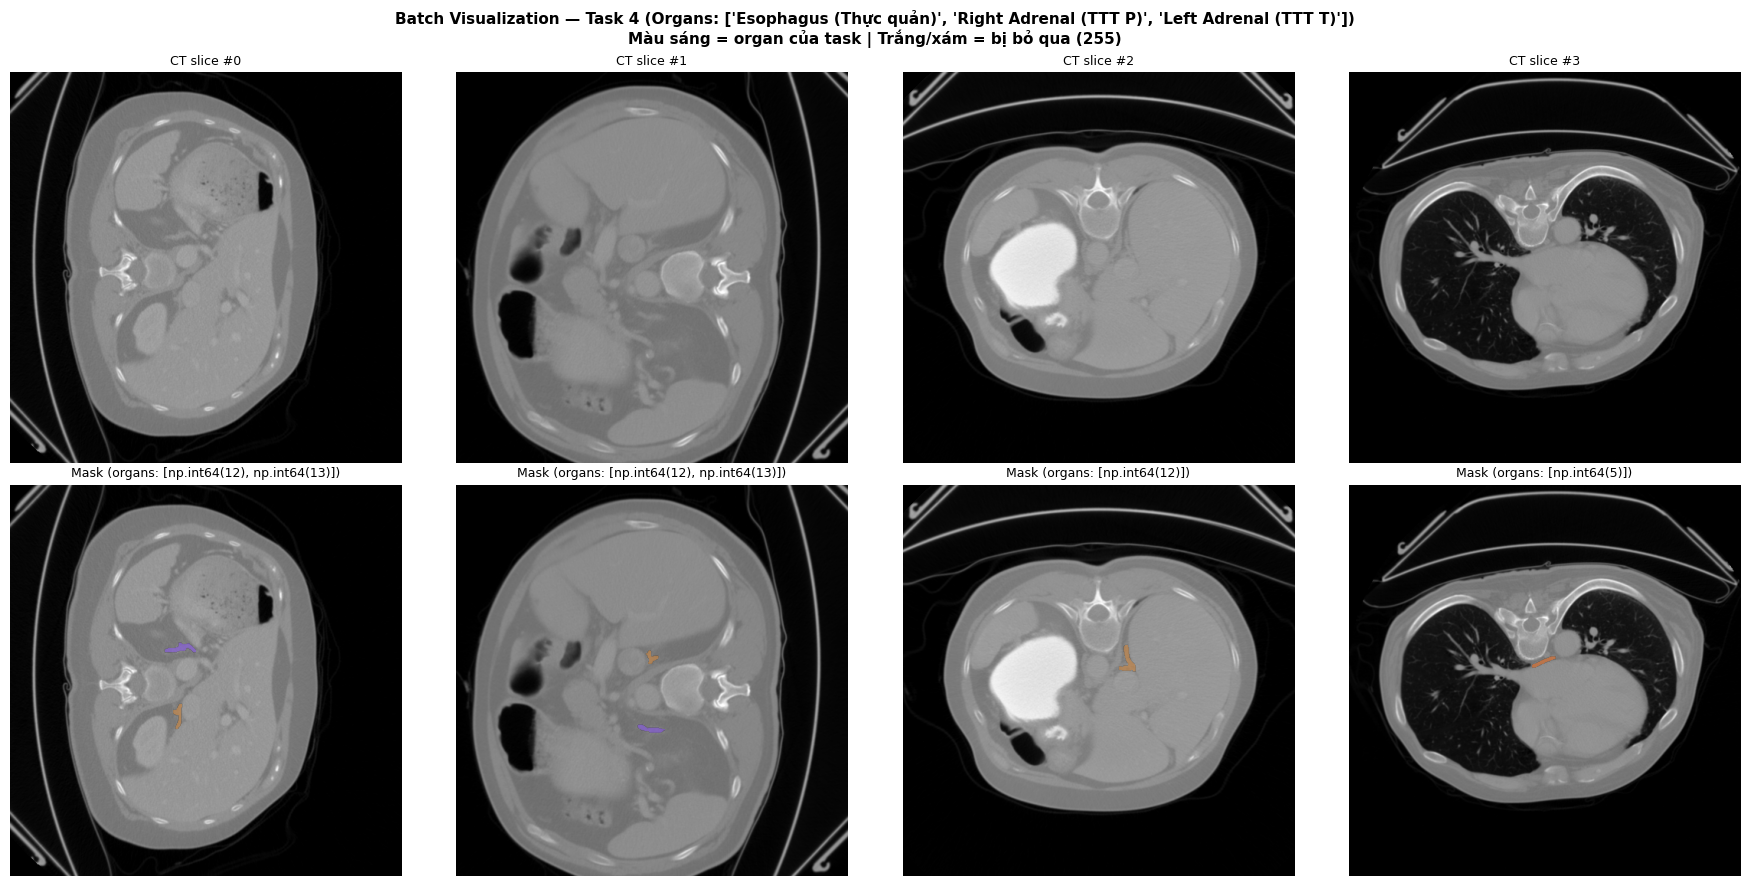

✅ Batch visualization OK!


In [ ]:
# Visualize 4 mẫu từ batch để xác nhận remap đúng
ORGAN_COLORS = [
    [0,0,0,0], [.9,.1,.1,.8], [.1,.5,.9,.8], [.1,.8,.9,.8],
    [.9,.8,.1,.8], [.9,.4,.1,.8], [.6,.1,.8,.8], [.1,.8,.4,.8],
    [.9,.1,.5,.8], [.3,.9,.9,.8], [.9,.6,.8,.8], [.3,.9,.3,.8],
    [.8,.5,.2,.8], [.5,.3,.9,.8],
]
ORGAN_CMAP = ListedColormap(ORGAN_COLORS)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Batch Visualization — Task {CURRENT_TASK} '
             f'(Organs: {[ORGAN_NAMES[o] for o in TASK_ORGANS[CURRENT_TASK]]})\n'
             f'Màu sáng = organ của task | Trắng/xám = bị bỏ qua (255)',
             fontsize=11, fontweight='bold')

n_show = min(4, ct_batch.shape[0])
for i in range(n_show):
    ct_np   = ct_batch[i, 0].numpy()     # (H, W)
    mask_np = mask_batch[i].numpy()      # (H, W) — có giá trị 255

    # Hiển thị CT
    axes[0, i].imshow(ct_np, cmap='gray', origin='upper')
    axes[0, i].set_title(f'CT slice #{i}', fontsize=9)
    axes[0, i].axis('off')

    # Hiển thị mask (255 = ignore → hiển thị màu riêng)
    display_mask = mask_np.copy().astype(float)
    display_mask[display_mask == 255] = np.nan  # NaN → matplotlib bỏ qua
    axes[0, i].imshow(ct_np, cmap='gray', origin='upper')

    axes[1, i].imshow(ct_np, cmap='gray', origin='upper')
    valid_mask = np.ma.masked_invalid(display_mask)
    axes[1, i].imshow(valid_mask, cmap=ORGAN_CMAP, vmin=0, vmax=13,
                      alpha=0.7, origin='upper')

    task_orgs = [o for o in np.unique(mask_np) if o not in [0, 255]]
    axes[1, i].set_title(f'Mask (organs: {task_orgs})', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print("✅ Batch visualization OK!")

## 🏗️ Step 6 — U-Net Model (ResNet-34 Encoder)

In [ ]:
# ============================================================
# Xây dựng U-Net với ResNet-34 encoder
# ============================================================
def build_unet(num_classes=14, encoder="resnet101", pretrained="imagenet"):
    model = smp.Unet(
        encoder_name    = encoder,
        encoder_weights = pretrained,
        in_channels     = 1,          # CT grayscale (1 kênh)
        classes         = num_classes,
        activation      = None,       # Không activation — trả về logits thô
                                      # → dùng với CrossEntropyLoss (đã có softmax bên trong)
    )
    return model


# Khởi tạo và move sang GPU
model = build_unet(
    num_classes = TRAIN_CFG["num_classes"],
    encoder     = TRAIN_CFG["encoder"],
    pretrained  = TRAIN_CFG["pretrained"],
).to(DEVICE)

# Thống kê model
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Architecture   : U-Net (encoder={TRAIN_CFG['encoder']})")
print(f"   Pretrained     : {TRAIN_CFG['pretrained']}")
print(f"   Input channels : 1 (grayscale CT)")
print(f"   Output channels: {TRAIN_CFG['num_classes']} (bg + 13 organs)")
print(f"   Total params   : {total_params:,}  ({total_params/1e6:.1f}M)")
print(f"   Trainable      : {trainable_params:,}")
print(f"   Device         : {DEVICE}")

✅ Model đã khởi tạo:
   Architecture   : U-Net (encoder=resnet34)
   Pretrained     : imagenet
   Input channels : 1 (grayscale CT)
   Output channels: 14 (bg + 13 organs)
   Total params   : 24,431,982  (24.4M)
   Trainable      : 24,431,982
   Device         : cuda

🧪 Test forward pass:
   Input  shape: (16, 1, 512, 512)  (B, C, H, W)
   Output shape: (16, 14, 512, 512) (B, 14, H, W) — 14 class logits
   ✅ VRAM sau khi tạo model: 0.48/14.6 GB (3%)


## 📉 Step 7 — Loss Functions

In [ ]:
# ============================================================
# Loss Functions cho CIL Segmentation
# ============================================================
# Hai thành phần:
#   1. CrossEntropyLoss  → phạt phân loại sai tại từng pixel
#   2. DiceLoss          → đo độ chồng lấp giữa predicted và ground truth
# Kết hợp: total_loss = alpha*CE + (1-alpha)*Dice
# ============================================================

class TaskDiceLoss(nn.Module):
    """
    Dice Loss tính CHỈ trên các channel của task hiện tại.

    Công thức Dice: 2 * |P ∩ T| / (|P| + |T|)
    Loss Dice = 1 - Dice   (muốn minimize → Dice càng gần 1 càng tốt)
    """

    def __init__(self, smooth=1e-5, ignore_index=255):
        super().__init__()
        self.smooth       = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, target, task_organs):
        """
        Args:
            logits      : (B, 14, H, W) float — raw logits của model
            target      : (B, H, W)  long  — mask đã remap {0, organs, 255}
            task_organs : list[int]  — organ IDs của task hiện tại
        Returns:
            scalar loss
        """
        # Áp softmax để đưa logits về xác suất [0, 1]
        probs = F.softmax(logits, dim=1)    # (B, 14, H, W)

        # Mask pixel hợp lệ (loại bỏ ignore_index)
        valid = (target != self.ignore_index).float()  # (B, H, W)

        dice_list = []
        # Tính dice cho từng organ của task (không bao gồm background)
        for c in task_organs:
            pred_c = probs[:, c] * valid              # (B, H, W)
            true_c = (target == c).float() * valid    # (B, H, W)

            # Tính per-sample rồi average
            intsec   = (pred_c * true_c).sum(dim=(1, 2))       # (B,)
            union    = pred_c.sum(dim=(1, 2)) + true_c.sum(dim=(1, 2))  # (B,)
            dice     = (2 * intsec + self.smooth) / (union + self.smooth)
            dice_list.append(1 - dice.mean())

        return torch.stack(dice_list).mean()


class CombinedLoss(nn.Module):
    """
    Combined Loss = alpha * CrossEntropy + (1 - alpha) * Dice

    - CE đảm bảo model học phân loại đúng từng pixel
    - Dice giải quyết vấn đề imbalance (không bị dominated bởi background)
    - Label smoothing giúp model tổng quát hơn, giảm overconfidence
    """

    def __init__(self, alpha=0.5, ignore_index=255, label_smoothing=0.0):
        super().__init__()
        self.alpha           = alpha
        self.ignore_index    = ignore_index
        self.label_smoothing = label_smoothing
        self.ce              = nn.CrossEntropyLoss(
            ignore_index=ignore_index,
            label_smoothing=label_smoothing,
        )
        self.dice            = TaskDiceLoss(ignore_index=ignore_index)

    def forward(self, logits, target, task_organs):
        """
        Args:
            logits      : (B, 14, H, W)
            target      : (B, H, W) long
            task_organs : list[int]
        Returns:
            total_loss, loss_ce, loss_dice  (để log riêng)
        """
        loss_ce   = self.ce(logits, target)
        loss_dice = self.dice(logits, target, task_organs)
        total     = self.alpha * loss_ce + (1 - self.alpha) * loss_dice
        return total, loss_ce.item(), loss_dice.item()


# Khởi tạo loss — B2: thêm label_smoothing
criterion = CombinedLoss(
    alpha           = TRAIN_CFG["loss_alpha"],
    ignore_index    = IGNORE_INDEX,
    label_smoothing = TRAIN_CFG["label_smoothing"],
)

print("✅ Loss functions đã khởi tạo:")
print(f"   Formula: {TRAIN_CFG['loss_alpha']}×CE + {1-TRAIN_CFG['loss_alpha']}×Dice")
print(f"   ignore_index   : {IGNORE_INDEX} (pixel = 255 bị bỏ qua)")
print(f"   label_smoothing: {TRAIN_CFG['label_smoothing']}")

# Test forward loss
print("\n🧪 Test CombinedLoss:")
with torch.no_grad():
    dummy_logits = torch.randn(2, 14, 64, 64).to(DEVICE)
    dummy_target = torch.zeros(2, 64, 64, dtype=torch.long).to(DEVICE)
    dummy_target[0, 20:40, 20:40] = 1    # Spleen
    dummy_target[0, 10:50, 10:50] = 6    # Liver
    dummy_target[0, 0:10, 0:10]   = 255  # Ignore
    total, ce_v, dice_v = criterion(dummy_logits, dummy_target, TASK_ORGANS[1])
    print(f"   Total loss: {total.item():.4f}")
    print(f"   CE loss   : {ce_v:.4f}")
    print(f"   Dice loss : {dice_v:.4f}")

✅ Loss functions đã khởi tạo:
   Formula: 0.5×CE + 0.5×Dice
   ignore_index   : 255 (pixel = 255 bị bỏ qua)
   label_smoothing: 0.0

🧪 Test CombinedLoss:
   Total loss: 2.0296
   CE loss   : 3.0877
   Dice loss : 0.9715


## 📊 Step 8 — Metrics (Dice Score per Organ)

In [ ]:
@torch.no_grad()
def compute_dice_per_organ(logits, target, task_organs, ignore_index=255):
    """
    Tính Dice Score cho từng organ của task hiện tại.

    Args:
        logits      : (B, 14, H, W) — raw logits của model
        target      : (B, H, W)     — mask đã remap
        task_organs : list[int]     — organ IDs của task
        ignore_index: int
    Returns:
        dict {organ_id: dice_score}  — mỗi giá trị trong [0, 1]
    """
    pred = torch.argmax(logits, dim=1)   # (B, H, W)
    valid = (target != ignore_index)     # (B, H, W) bool

    result = {}
    for organ_id in task_organs:
        pred_o = (pred   == organ_id) & valid
        true_o = (target == organ_id) & valid

        intersection = (pred_o & true_o).sum().item()
        pred_sum     = pred_o.sum().item()
        true_sum     = true_o.sum().item()

        if pred_sum + true_sum == 0:
            dice = float('nan')
        else:
            dice = 2 * intersection / (pred_sum + true_sum)

        result[organ_id] = dice

    return result


# ============================================================
# A1: compute_iou_per_organ — tính IoU global cho mỗi organ
# IoU = intersection / (pred_sum + true_sum - intersection)
# Tính từ tích lũy global (không per-sample) → ổn định với organs nhỏ
# ============================================================
@torch.no_grad()
def compute_iou_per_organ(pred, target, organ_ids, ignore_index=255):
    """
    Tính IoU cho từng organ từ prediction và target đã tích lũy.

    Args:
        pred        : (B, H, W) long — nhãn dự đoán (argmax)
        target      : (B, H, W) long — ground truth mask
        organ_ids   : list[int]      — organ IDs cần tính
        ignore_index: int
    Returns:
        dict {organ_id: iou}  — mỗi giá trị trong [0, 1], NaN nếu vắng mặt
    """
    valid = (target != ignore_index)
    result = {}
    for organ_id in organ_ids:
        pred_o = (pred == organ_id) & valid
        true_o = (target == organ_id) & valid

        inter    = (pred_o & true_o).sum().item()
        pred_sum = pred_o.sum().item()
        true_sum = true_o.sum().item()
        union    = pred_sum + true_sum - inter

        if union == 0:
            result[organ_id] = float('nan')
        else:
            result[organ_id] = inter / union

    return result


def format_dice_table(dice_dict, task_organs, epoch=None):
    """In bảng Dice Score đẹp sau mỗi epoch."""
    header = f"  {'Epoch':>6}" if epoch is not None else ""
    print(f"\n{header}  {'Organ':30s}  {'Dice':>8}  {'Status':>10}")
    print("  " + "-" * 58)

    valid_dices = []
    for organ_id in task_organs:
        dice = dice_dict.get(organ_id, float('nan'))
        name = ORGAN_NAMES.get(organ_id, f"Organ {organ_id}")

        if not np.isnan(dice):
            valid_dices.append(dice)
            status = "Good" if dice >= 0.7 else ("Fair" if dice >= 0.5 else "Poor")
            ep_str = f"{epoch:6d}" if epoch is not None else ""
            print(f"  {ep_str}  {name:30s}  {dice:8.4f}  {status}")
        else:
            ep_str = f"{epoch:6d}" if epoch is not None else ""
            print(f"  {ep_str}  {name:30s}  {'N/A':>8}  (không có trong batch)")

    if valid_dices:
        mean_dice = np.mean(valid_dices)
        print("  " + "=" * 58)
        ep_str = f"{epoch:6d}" if epoch is not None else ""
        print(f"  {ep_str}  {'Mean Dice':30s}  {mean_dice:8.4f}")

    return np.mean(valid_dices) if valid_dices else 0.0

## 🏋️ Step 9 — Trainer Class

In [ ]:
class Trainer:
    """
    Trainer cho CIL Segmentation với U-Net.
    Hỗ trợ:
      - Training / Validation trên task hiện tại
      - CIL Evaluation trên TẤT CẢ organs đã học (DSC + mIoU)
      - Tính Forgetting metrics
      - Load model weights từ task trước (không load optimizer)
      - Checkpoint save/load, logging
      - Cosine Annealing Warm Restarts scheduler (B3)
    """

    def __init__(self, model, optimizer, criterion, scheduler,
                 device, task_id, checkpoint_dir, log_dir,
                 save_every=5, ignore_index=255):
        self.model          = model
        self.optimizer      = optimizer
        self.criterion      = criterion
        self.scheduler      = scheduler
        self.device         = device
        self.task_id        = task_id
        self.task_organs    = TASK_ORGANS[task_id]
        self.all_learned    = ALL_PAST_ORGANS[task_id]
        self.checkpoint_dir = checkpoint_dir
        self.log_dir        = log_dir
        self.save_every     = save_every
        self.ignore_index   = ignore_index

        self.best_val_dice  = 0.0
        self.history        = {"train_loss": [], "val_loss": [],
                                "val_dice": [], "lr": []}

        # A5: lưu mIoU sau mỗi task → tính avg_miou tích lũy
        self.miou_history   = []

        # B3: scheduler gọi sau mỗi batch (CosineAnnealingWarmRestarts)
        self.on_batch_scheduler = None
        self.use_amp = TRAIN_CFG.get("use_amp", False) and self.device.type == "cuda"
        self.scaler  = torch.amp.GradScaler("cuda", enabled=self.use_amp)

    # ----------------------------------------------------------
    def train_epoch(self, loader):
        """Chạy 1 epoch training, trả về loss trung bình."""
        self.model.train()
        total_loss = total_ce = total_dice = 0.0

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)

            self.optimizer.zero_grad()

            # ── AMP: autocast forward pass ──
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)       # (B, 14, H, W)
                loss, ce_v, dice_v = self.criterion(
                    logits, mask_batch, self.task_organs
                )

            # ── AMP: scaled backward + unscale + clip + step ──
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            # B3: Cosine scheduler step sau mỗi batch
            if self.on_batch_scheduler is not None:
                self.on_batch_scheduler.step()

            total_loss += loss.item()
            total_ce   += ce_v
            total_dice += dice_v

        n = len(loader)
        return total_loss/n, total_ce/n, total_dice/n

    # ----------------------------------------------------------
    # VALIDATION (task hiện tại — dùng trong training loop)
    # ----------------------------------------------------------
    @torch.no_grad()
    def validate(self, loader):
        """
        Validate trên val set của TASK HIỆN TẠI.
        loader dùng task_id=CURRENT_TASK (mask đã remap).
        Dùng để monitor training — KHÔNG phải CIL evaluation.
        """
        self.model.eval()
        total_loss = 0.0

        inter = defaultdict(float)
        union = defaultdict(float)

        for ct_batch, mask_batch in loader:

            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)
                loss, _, _ = self.criterion(logits, mask_batch, self.task_organs)
            total_loss += loss.item()

            pred  = torch.argmax(logits, dim=1)
            valid = (mask_batch != self.ignore_index)
            for organ_id in self.task_organs:
                pred_o = (pred  == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid
                inter[organ_id] += (pred_o & true_o).sum().item()
                union[organ_id] += pred_o.sum().item() + true_o.sum().item()

        val_loss = total_loss / len(loader)

        dice_dict = {}
        for organ_id in self.task_organs:
            if union[organ_id] > 0:
                dice_dict[organ_id] = 2 * inter[organ_id] / union[organ_id]
            else:
                dice_dict[organ_id] = float('nan')

        return val_loss, dice_dict

    # ----------------------------------------------------------
    # CIL EVALUATION (tất cả organs đã học — DSC + mIoU)
    # ----------------------------------------------------------
    @torch.no_grad()
    def evaluate_cil(self, eval_loader):
        """
        Đánh giá CIL: tính DSC + IoU trên TẤT CẢ organs đã học.

        Fix A1: thêm valid mask (exclude ignore_index=255)
        Fix A2: tích lũy thêm IoU
        Fix A3: phân nhóm C1 cố định (TASK_ORGANS[1]) thay vì old/new

        Returns:
            dice_all : dict {organ_id: dice}
            iou_all  : dict {organ_id: iou}
            dice_c1  : dict (chỉ C1=[6,7])
            dice_c2t : dict (C2..T)
            iou_c1   : dict
            iou_c2t  : dict
        """
        self.model.eval()

        # Tích lũy global counters cho DSC và IoU
        inter     = defaultdict(float)   # intersection
        pred_sum  = defaultdict(float)   # tổng pixel predicted
        true_sum  = defaultdict(float)   # tổng pixel ground truth

        for ct_batch, mask_batch in eval_loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)
            pred = torch.argmax(logits, dim=1)

            # Exclude ignore_index pixels
            valid = (mask_batch != self.ignore_index)

            for organ_id in self.all_learned:
                pred_o = (pred == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid

                inter[organ_id]    += (pred_o & true_o).sum().item()
                pred_sum[organ_id] += pred_o.sum().item()
                true_sum[organ_id] += true_o.sum().item()

        # --- Tính DSC và IoU từ global counters ---
        dice_all = {}
        iou_all  = {}
        for organ_id in self.all_learned:
            dice_denom = pred_sum[organ_id] + true_sum[organ_id]
            iou_denom  = dice_denom - inter[organ_id]  # pred+true-inter

            # DSC = 2*inter / (pred+true)
            if dice_denom > 0:
                dice_all[organ_id] = 2 * inter[organ_id] / dice_denom
            else:
                dice_all[organ_id] = float('nan')

            # IoU = inter / (pred+true-inter)
            if iou_denom > 0:
                iou_all[organ_id] = inter[organ_id] / iou_denom
            else:
                iou_all[organ_id] = float('nan')

        # FIX LỖI 3: phân nhóm C1 cố định, C2:T = phần còn lại
        c1_organs  = TASK_ORGANS[1]   # luôn [6, 7]
        c2t_organs = [o for o in self.all_learned if o not in c1_organs]

        dice_c1  = {o: dice_all[o] for o in c1_organs  if o in dice_all}
        dice_c2t = {o: dice_all[o] for o in c2t_organs if o in dice_all}
        iou_c1   = {o: iou_all[o]  for o in c1_organs  if o in iou_all}
        iou_c2t  = {o: iou_all[o]  for o in c2t_organs if o in iou_all}

        return dice_all, iou_all, dice_c1, dice_c2t, iou_c1, iou_c2t

    # ----------------------------------------------------------
    # FORGETTING METRICS
    # ----------------------------------------------------------
    def compute_forgetting(self, current_dice, prev_task_dice):
        """
        Tính Forgetting cho các organs cũ.

        FIX LỖI 4: NaN → skip (không gán 0 — tránh phóng đại forgetting)

        Args:
            current_dice   : dict {organ_id: dice} sau task hiện tại
            prev_task_dice : dict {organ_id: dice} ngay sau task trước
        Returns:
            forgetting : dict {organ_id: float} dương = bị quên
            mean_fgt   : float trung bình forgetting
        """
        forgetting = {}
        for organ_id, old_dice in prev_task_dice.items():
            if np.isnan(old_dice):
                continue
            new_dice = current_dice.get(organ_id, float('nan'))
            # FIX: skip organ vắng mặt thay vì gán 0
            if np.isnan(new_dice):
                continue
            forgetting[organ_id] = old_dice - new_dice

        valid_fgt = [v for v in forgetting.values() if not np.isnan(v)]
        mean_fgt = np.mean(valid_fgt) if valid_fgt else float('nan')

        return forgetting, mean_fgt

    def _compute_performance_row(self, dice_all):
        """
        Tính hàng R[task_id][j] cho j = 1..task_id.

        R[i][j] = mean DSC của organs thuộc Task j,
                  đánh giá bằng model sau khi train xong Task i.

        Args:
            dice_all : dict {organ_id: dice} từ evaluate_cil()
        Returns:
            row_dict : dict {j: R[i][j]} cho j = 1..task_id
        """
        row = {}
        for j in range(1, self.task_id + 1):
            task_j_organs = TASK_ORGANS[j]
            dices = [dice_all.get(o, float('nan')) for o in task_j_organs]
            valid = [d for d in dices if not np.isnan(d)]
            row[j] = round(np.mean(valid), 4) if valid else None
        return row

    def _print_cil_report(self, dice_all, iou_all,
                          dice_c1, dice_c2t, iou_c1, iou_c2t,
                          prev_task_dice=None):
        """
        A5: Báo cáo CIL evaluation đầy đủ — 2 hệ thống DSC + mIoU.

        Returns:
            dict chứa tất cả metrics tổng hợp (dùng cho JSON save)
        """
        # --- Helper: tính mean bỏ NaN ---
        def _mean_valid(d):
            vals = [v for v in d.values() if not np.isnan(v)]
            return np.mean(vals) if vals else float('nan')

        dsc_old = _mean_valid(dice_c1)
        dsc_new = _mean_valid(dice_c2t)
        dsc_all = _mean_valid(dice_all)

        miou_c1_val  = _mean_valid(iou_c1)
        miou_c2t_val = _mean_valid(iou_c2t)
        miou_all_val = _mean_valid(iou_all)

        # Cập nhật miou_history → tính avg_miou tích lũy
        if not np.isnan(miou_all_val):
            self.miou_history.append(miou_all_val)
        avg_miou = np.mean(self.miou_history) if self.miou_history else float('nan')

        # --- In báo cáo ---
        print(f"\n{'='*72}")
        print(f"  CIL EVALUATION — Sau Task {self.task_id}")
        print(f"  Organs da hoc ({len(self.all_learned)}): "
              f"{[ORGAN_NAMES[o] for o in self.all_learned]}")
        print(f"{'='*72}")

        # ---- HỆ THỐNG 1: DSC ----
        print(f"\n  ┌─── DSC (Dice Similarity Coefficient) ───┐")
        print(f"  │  {'Organ':30s}  {'DSC':>8}  {'Status':>8}  │")
        print(f"  │  {'-'*52}  │")

        # C1 organs (rigidity)
        print(f"  │  [C1 — Rigidity] TASK_ORGANS[1] = {TASK_ORGANS[1]}")
        for o in TASK_ORGANS[1]:
            d = dice_c1.get(o, float('nan'))
            name = ORGAN_NAMES.get(o, f"Organ {o}")
            if not np.isnan(d):
                st = "Good" if d >= 0.7 else ("Fair" if d >= 0.5 else "Poor")
                print(f"  │  {name:30s}  {d:8.4f}  {st:>8}  │")
            else:
                print(f"  │  {name:30s}  {'N/A':>8}  {'---':>8}  │")

        # C2:T organs (plasticity)
        if dice_c2t:
            print(f"  │  [C2:T — Plasticity]")
            for o in [x for x in self.all_learned if x not in TASK_ORGANS[1]]:
                d = dice_c2t.get(o, float('nan'))
                name = ORGAN_NAMES.get(o, f"Organ {o}")
                if not np.isnan(d):
                    st = "Good" if d >= 0.7 else ("Fair" if d >= 0.5 else "Poor")
                    print(f"  │  {name:30s}  {d:8.4f}  {st:>8}  │")
                else:
                    print(f"  │  {name:30s}  {'N/A':>8}  {'---':>8}  │")

        print(f"  │{'─'*56}│")
        print(f"  │  DSC Old (C1)  : {dsc_old:8.4f}                        │")
        if dice_c2t:
            print(f"  │  DSC New (C2:T): {dsc_new:8.4f}                        │")
        print(f"  │  DSC All       : {dsc_all:8.4f}                        │")
        print(f"  └{'─'*56}┘")

        # ---- HỆ THỐNG 2: mIoU ----
        print(f"\n  ┌─── mIoU (mean Intersection over Union) ───┐")
        print(f"  │  {'Organ':30s}  {'IoU':>8}  │")
        print(f"  │  {'-'*42}  │")
        for o in self.all_learned:
            iou_v = iou_all.get(o, float('nan'))
            name = ORGAN_NAMES.get(o, f"Organ {o}")
            if not np.isnan(iou_v):
                print(f"  │  {name:30s}  {iou_v:8.4f}  │")
            else:
                print(f"  │  {name:30s}  {'N/A':>8}  │")
        print(f"  │{'─'*46}│")
        print(f"  │  mIoU C1     : {miou_c1_val:8.4f}                    │")
        if iou_c2t:
            print(f"  │  mIoU C2:T  : {miou_c2t_val:8.4f}                    │")
        print(f"  │  mIoU All   : {miou_all_val:8.4f}                    │")
        print(f"  │  avg mIoU   : {avg_miou:8.4f}  "
              f"(over {len(self.miou_history)} tasks)     │")
        print(f"  └{'─'*46}┘")

        # ---- FORGETTING ----
        fgt_dict, mean_fgt = {}, 0.0
        if prev_task_dice:
            fgt_dict, mean_fgt = self.compute_forgetting(dice_all, prev_task_dice)
            print(f"\n  ┌─── Forgetting (positive = forgot) ───┐")
            for organ_id, fgt in fgt_dict.items():
                name = ORGAN_NAMES.get(organ_id, f"Organ {organ_id}")
                marker = " ← severe!" if fgt > 0.2 else ""
                print(f"  │  {name:30s}  {fgt:+.4f}{marker}")
            print(f"  │  {'Mean Forgetting':30s}  {mean_fgt:+.4f}")
            print(f"  └{'─'*46}┘")

        print(f"\n  ┌─── Performance Matrix R[{self.task_id}][j] ───┐")
        for j in range(1, self.task_id + 1):
            task_j_organs = TASK_ORGANS[j]
            dices = [dice_all.get(o, float('nan')) for o in task_j_organs]
            valid = [d for d in dices if not np.isnan(d)]
            r_ij = np.mean(valid) if valid else float('nan')
            organs_str = ", ".join([ORGAN_NAMES[o][:15] for o in task_j_organs])
            marker = " ← current" if j == self.task_id else ""
            if not np.isnan(r_ij):
                print(f"  │  R[{self.task_id}][{j}] = {r_ij:.4f}"
                      f"  ({organs_str}){marker}")
            else:
                print(f"  │  R[{self.task_id}][{j}] = N/A"
                      f"  ({organs_str}){marker}")
        print(f"  └{'─'*50}┘")

        # --- Summary dict ---
        return {
            "dsc_old": round(dsc_old, 4) if not np.isnan(dsc_old) else None,
            "dsc_new": round(dsc_new, 4) if not np.isnan(dsc_new) else None,
            "dsc_all": round(dsc_all, 4) if not np.isnan(dsc_all) else None,
            "miou_c1": round(miou_c1_val, 4) if not np.isnan(miou_c1_val) else None,
            "miou_c2t": round(miou_c2t_val, 4) if not np.isnan(miou_c2t_val) else None,
            "miou_all": round(miou_all_val, 4) if not np.isnan(miou_all_val) else None,
            "avg_miou": round(avg_miou, 4) if not np.isnan(avg_miou) else None,
            "forgetting": fgt_dict,
            "mean_forgetting": round(mean_fgt, 4),
            "dice_per_organ_id": {str(k): round(v, 4)for k, v in dice_all.items() if not np.isnan(v)},

        }

    # ----------------------------------------------------------
    def save_checkpoint(self, epoch, val_dice, is_best=False):
        """Lưu checkpoint vào Google Drive."""
        state = {
            "epoch"           : epoch,
            "task_id"         : self.task_id,
            "model_state"     : self.model.state_dict(),
            "optimizer_state" : self.optimizer.state_dict(),
            "scheduler_state" : self.scheduler.state_dict() if self.scheduler else None,
            "scaler_state"    : self.scaler.state_dict(),
            "val_dice"        : val_dice,
            "best_val_dice"   : self.best_val_dice,
            "history"         : self.history,
            "train_cfg"       : TRAIN_CFG,
            "miou_history"    : self.miou_history,
        }

        # Lưu checkpoint định kỳ
        ckpt_path = os.path.join(
            self.checkpoint_dir,
            f"task{self.task_id}_epoch{epoch:03d}.pth"
        )
        torch.save(state, ckpt_path)

        # Lưu riêng checkpoint tốt nhất
        if is_best:
            best_path = os.path.join(
                self.checkpoint_dir,
                f"task{self.task_id}_best.pth"
            )
            torch.save(state, best_path)
            print(f"     💾 Best checkpoint! Dice={val_dice:.4f} → {best_path}")

    # ----------------------------------------------------------
    # LOAD: Resume cùng task (load cả optimizer)
    # ----------------------------------------------------------
    def load_checkpoint(self, path):
        """Load checkpoint để RESUME training cùng task."""
        state = torch.load(path, map_location=self.device, weights_only=False)
        self.model.load_state_dict(state["model_state"])
        self.optimizer.load_state_dict(state["optimizer_state"])
        if self.scheduler and state["scheduler_state"]:
            self.scheduler.load_state_dict(state["scheduler_state"])
        if "scaler_state" in state:
            self.scaler.load_state_dict(state["scaler_state"])
        self.best_val_dice = state["best_val_dice"]
        self.history       = state["history"]
        start_epoch        = state["epoch"] + 1
        print(f"Resume checkpoint: epoch={state['epoch']}, "
              f"best_dice={state['best_val_dice']:.4f}")
        return start_epoch

    # ----------------------------------------------------------
    # LOAD: Weights từ task trước (KHÔNG load optimizer)
    # ----------------------------------------------------------
    def load_prev_task(self, path):
        """
        Load CHỈ model weights từ checkpoint task trước.
        KHÔNG load optimizer/scheduler (reset cho task mới).
        Dùng khi bắt đầu train task 2, 3, 4.

        Returns:
            state dict (để lấy thêm thông tin nếu cần)
        """
        state = torch.load(path, map_location=self.device, weights_only=False)
        self.model.load_state_dict(state["model_state"])
        src_task  = state["task_id"]
        src_epoch = state["epoch"]
        src_dice  = state.get("best_val_dice", state.get("val_dice", 0))
        print(f"Loaded model from Task {src_task} "
              f"(epoch {src_epoch}, dice={src_dice:.4f})")
        print(f"   Optimizer/Scheduler: RESET (not loaded from prev task)")
        return state

    # ----------------------------------------------------------
    # MAIN TRAINING LOOP
    # ----------------------------------------------------------
    def fit(self, train_loader, val_loader, n_epochs, start_epoch=1,
            eval_loader=None, prev_task_dice=None):
        """
        Vòng lặp training chính.

        Args:
            train_loader   : DataLoader training (task_id = CURRENT_TASK)
            val_loader     : DataLoader validation (task_id = CURRENT_TASK)
            n_epochs       : số epoch cần train
            start_epoch    : bắt đầu từ epoch nào (dùng khi resume)
            eval_loader    : DataLoader CIL eval (task_id = None, full mask)
            prev_task_dice : dict {organ_id: dice} từ task trước
        Returns:
            (dice_all, iou_all) nếu có eval_loader, None nếu không
        """
        # B3: nếu scheduler là cosine → gọi step() sau mỗi batch
        scheduler_type = TRAIN_CFG.get("scheduler_type", "plateau")
        if scheduler_type == "cosine" and self.scheduler is not None:
            self.on_batch_scheduler = self.scheduler
        else:
            self.on_batch_scheduler = None

        print(f"\n{'='*65}")
        print(f"  Training Task {self.task_id} "
              f"-- Organs: {[ORGAN_NAMES[o] for o in self.task_organs]}")
        print(f"  Epochs: {start_epoch} -> {n_epochs} "
              f"| Save every {self.save_every} epochs")
        print(f"  Scheduler: {scheduler_type}")
        if self.task_id > 1:
            print(f"  All learned organs: "
                  f"{[ORGAN_NAMES[o] for o in self.all_learned]}")
        print(f"{'='*65}")

        for epoch in range(start_epoch, n_epochs + 1):
            t0 = time.time()

            train_loss, tr_ce, tr_dice = self.train_epoch(train_loader)
            val_loss, dice_dict = self.validate(val_loader)

            # B3: ReduceLROnPlateau step sau epoch, cosine đã step trong batch
            if self.scheduler and scheduler_type == "plateau":
                self.scheduler.step(val_loss)

            current_lr = self.optimizer.param_groups[0]['lr']
            mean_dice  = np.nanmean(list(dice_dict.values()))
            elapsed    = time.time() - t0

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_dice"].append(mean_dice)
            self.history["lr"].append(current_lr)

            print(f"\n  Epoch {epoch:3d}/{n_epochs} "
                  f"({elapsed:.0f}s) "
                  f"| LR={current_lr:.2e}")
            print(f"  Train: loss={train_loss:.4f} "
                  f"(CE={tr_ce:.4f}, Dice={tr_dice:.4f})")
            print(f"  Val  : loss={val_loss:.4f} "
                  f"| Mean Dice={mean_dice:.4f}")

            format_dice_table(dice_dict, self.task_organs, epoch=epoch)
            log_vram(f"epoch {epoch}")

            is_best = mean_dice > self.best_val_dice
            if is_best:
                self.best_val_dice = mean_dice

            if epoch % self.save_every == 0 or is_best:
                self.save_checkpoint(epoch, mean_dice, is_best)

        self._save_log()

        print(f"\n{'='*65}")
        print(f"  Training hoan tat!")
        print(f"  Best Val Dice (task {self.task_id}): {self.best_val_dice:.4f}")
        print(f"  Checkpoint: {self.checkpoint_dir}/task{self.task_id}_best.pth")
        print(f"{'='*65}")

        # --- CIL Evaluation sau training (DSC + mIoU) ---
        if eval_loader is not None:
            print(f"\n  Running CIL evaluation on ALL learned organs...")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            (dice_all, iou_all,
             dice_c1, dice_c2t,
             iou_c1, iou_c2t) = self.evaluate_cil(eval_loader)

            # In báo cáo và nhận summary metrics
            summary = self._print_cil_report(
                dice_all, iou_all,
                dice_c1, dice_c2t, iou_c1, iou_c2t,
                prev_task_dice,
            )

            # A6: JSON schema mới — đầy đủ DSC + mIoU + forgetting
            perf_row = self._compute_performance_row(dice_all)
            cil_results = {
                "task_id": self.task_id,
                "dsc": {
                    "old": summary["dsc_old"],
                    "new": summary["dsc_new"],
                    "all": summary["dsc_all"],
                    "per_organ": {
                        ORGAN_NAMES[k]: round(v, 4)
                        for k, v in dice_all.items() if not np.isnan(v)
                    },
                },
                "miou": {
                    "c1":  summary["miou_c1"],
                    "c2t": summary["miou_c2t"],
                    "all": summary["miou_all"],
                    "avg": summary["avg_miou"],
                    "per_organ": {
                        ORGAN_NAMES[k]: round(v, 4)
                        for k, v in iou_all.items() if not np.isnan(v)
                    },
                },
                "forgetting": {
                    "per_organ": {
                        ORGAN_NAMES.get(k, f"Organ {k}"): round(v, 4)
                        for k, v in summary["forgetting"].items()
                    },
                    "mean": summary["mean_forgetting"],
                },
                # ── NEW: Performance Matrix Row ──
                "performance_matrix_row": {
                    f"R[{self.task_id}][{j}]": v
                    for j, v in perf_row.items()
                },
                # ── NEW: dice_per_organ_id (key = organ_id số) ──
                "dice_per_organ_id": {
                    str(k): round(v, 4)
                    for k, v in dice_all.items() if not np.isnan(v)
                },
                # backward compat
                "overall_dice": summary["dsc_all"],
                "dice_per_organ": {
                    ORGAN_NAMES[k]: round(v, 4)
                    for k, v in dice_all.items() if not np.isnan(v)
                },
            }

            cil_path = os.path.join(
                self.log_dir, f"task{self.task_id}_cil_results.json"
            )
            with open(cil_path, 'w') as f:
                json.dump(cil_results, f, indent=2, ensure_ascii=False)
            print(f"\n   CIL results saved: {cil_path}")

            return dice_all, iou_all

        return None

    def _save_log(self):
        import csv
        log_path = os.path.join(self.log_dir, f"task{self.task_id}_history.csv")
        with open(log_path, 'w', newline='') as f:
            writer = csv.DictWriter(f,
                fieldnames=["epoch","train_loss","val_loss","val_dice","lr"])
            writer.writeheader()
            for i, (tl, vl, vd, lr) in enumerate(
                    zip(self.history["train_loss"], self.history["val_loss"],
                        self.history["val_dice"], self.history["lr"]), 1):
                writer.writerow({"epoch":i,"train_loss":tl,
                                  "val_loss":vl,"val_dice":vd,"lr":lr})
        print(f"   Log saved: {log_path}")

## 🎯 Step 10 — Chạy Training Task 1

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = TRAIN_CFG["lr"],
    weight_decay = 1e-4,
)

# B3: Chọn scheduler dựa trên TRAIN_CFG
scheduler_type = TRAIN_CFG.get("scheduler_type", "plateau")

if scheduler_type == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0     = TRAIN_CFG["cosine_T0"],       # restart mỗi T_0 epoch
        T_mult  = TRAIN_CFG["cosine_T_mult"],    # chu kỳ không đổi
        eta_min = TRAIN_CFG["cosine_eta_min"],
    )
    sched_info = (f"CosineAnnealingWarmRestarts "
                  f"(T_0={TRAIN_CFG['cosine_T0']}, "
                  f"eta_min={TRAIN_CFG['cosine_eta_min']})")
else:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode     = 'min',
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-6,
    )
    sched_info = "ReduceLROnPlateau (patience=5, factor=0.5)"

trainer = Trainer(
    model          = model,
    optimizer      = optimizer,
    criterion      = criterion,
    scheduler      = scheduler,
    device         = DEVICE,
    task_id        = CURRENT_TASK,
    checkpoint_dir = CHECKPOINT_DIR,
    log_dir        = LOG_DIR,
    save_every     = TRAIN_CFG["save_every"],
    ignore_index   = IGNORE_INDEX,
)

print("✅ Sẵn sàng training!")
print(f"   Optimizer       : AdamW (lr={TRAIN_CFG['lr']}, wd=1e-4)")
print(f"   Scheduler       : {sched_info}")
print(f"   Label smoothing : {TRAIN_CFG['label_smoothing']}")
print(f"   Task            : {CURRENT_TASK} — {[ORGAN_NAMES[o] for o in TASK_ORGANS[CURRENT_TASK]]}")
print(f"   Epochs          : {TRAIN_CFG['n_epochs']}")

# ============================================================
# CIL Eval DataLoader — PHẢI dùng slices của TẤT CẢ organs đã học
# ============================================================
# KHÔNG dùng val_records vì val_records chỉ chứa slices có organ
# của CURRENT_TASK. Các slices chứa organ Task 1 mà không có
# organ Task 2 sẽ bị bỏ qua → Dice của old organs bị underestimate.
# ============================================================

all_learned_organs = ALL_PAST_ORGANS[CURRENT_TASK]

# Lấy tất cả val slices có ÍT NHẤT 1 organ trong all_learned_organs
eval_records = [
    r for r in metadata
    if r["volume_id"] in val_vol_ids                          # chỉ vol thuộc val split
    and set(all_learned_organs) & set(r["organs_present"])    # có ít nhất 1 organ đã học
]

print(f"📊 eval_records cho Task {CURRENT_TASK}:")
print(f"   All learned organs : {[ORGAN_NAMES[o] for o in all_learned_organs]}")
print(f"   val_records        : {len(val_records):,} slices  (chỉ organ Task {CURRENT_TASK})")
print(f"   eval_records       : {len(eval_records):,} slices (tất cả organs đã học) ← dùng cái này")

# Tạo eval_dataset từ eval_records (full mask, không remap)
eval_dataset = BTCVDataset(
    records    = eval_records,
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    task_id    = None,
    augment    = False,
)
eval_loader = DataLoader(
    eval_dataset,
    batch_size         = TRAIN_CFG["batch_size"],
    shuffle            = False,
    num_workers        = TRAIN_CFG["num_workers"],
    pin_memory         = True,
    persistent_workers = TRAIN_CFG["num_workers"] > 0,
)
print(f"   eval_loader        : {len(eval_dataset):,} slices → {len(eval_loader):,} batches")

# ============================================================
# Load prev task dice (nếu task > 1)
# ============================================================
prev_task_dice = None
if CURRENT_TASK > 1:
    prev_task = CURRENT_TASK - 1
    candidates = [
        f"{LOG_DIR}/task{prev_task}_cil_results.json",
        f"{LOG_DIR}/task{prev_task}_eval_results.json",
    ]
    prev_path = None
    for p in candidates:
        if os.path.exists(p):
            prev_path = p
            break

    if prev_path is not None:
        with open(prev_path, 'r') as f:
            prev_results = json.load(f)

        prev_task_dice = {}
        # Ưu tiên dice_per_organ_id (key = organ_id số) — nhanh và chính xác
        dice_by_id = prev_results.get("dice_per_organ_id", {})
        if dice_by_id:
            for oid_str, dice in dice_by_id.items():
                prev_task_dice[int(oid_str)] = dice
        else:
            # Fallback: dùng dice_per_organ (key = organ name)
            dice_data = prev_results.get("dice_per_organ", {})
            for organ_name, dice in dice_data.items():
                for oid, oname in ORGAN_NAMES.items():
                    if oname == organ_name:
                        prev_task_dice[oid] = dice
                        break


        print(f"   Prev task dice loaded from: {prev_path}")
        for oid, d in sorted(prev_task_dice.items()):
            print(f"     {ORGAN_NAMES[oid]:30s}: {d:.4f}")
    else:
        print(f"   WARNING: No results file found for task {prev_task}.")
        print(f"   Looked for: {candidates}")
        print(f"   Forgetting will NOT be computed.")

# Resume hoặc load từ task trước
start_epoch = 1
if CURRENT_TASK > 1:
    prev_best = f"{CHECKPOINT_DIR}/task{CURRENT_TASK - 1}_best.pth"
    if os.path.exists(prev_best):
        trainer.load_prev_task(prev_best)
    else:
        print(f"   WARNING: {prev_best} not found!")

✅ Sẵn sàng training!
   Optimizer       : AdamW (lr=0.0003, wd=1e-4)
   Scheduler       : ReduceLROnPlateau (patience=5, factor=0.5)
   Label smoothing : 0.0
   Task            : 4 — ['Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']
   Epochs          : 15
📊 eval_records cho Task 4:
   All learned organs : ['Liver (Gan)', 'Stomach (Dạ dày)', 'Spleen (Lách)', 'Right Kidney (Thận P)', 'Left Kidney (Thận T)', 'Aorta (ĐM chủ)', 'Gallbladder (Túi mật)', 'IVC (TM chủ dưới)', 'Portal Vein (TM cửa)', 'Pancreas (Tụy)', 'Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']
   val_records        : 197 slices  (chỉ organ Task 4)
   eval_records       : 368 slices (tất cả organs đã học) ← dùng cái này
  📦 BTCVDataset [EVAL]: 368 slices, task_id=None
   eval_loader        : 368 slices → 23 batches
   Prev task dice loaded from: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/task3_cil_results.json
     Spleen (Lách)     

In [ ]:
cil_result = trainer.fit(
    train_loader   = train_loader,
    val_loader     = val_loader,
    n_epochs       = TRAIN_CFG["n_epochs"],
    start_epoch    = start_epoch,
    eval_loader    = eval_loader,
    prev_task_dice = prev_task_dice,
)

# Unpack kết quả CIL (dice_all, iou_all) nếu có
if cil_result is not None:
    dice_all_result, iou_all_result = cil_result
    print(f"\n📊 CIL Result summary:")
    print(f"   dice_all keys: {list(dice_all_result.keys())}")
    print(f"   iou_all  keys: {list(iou_all_result.keys())}")


  Training Task 4 -- Organs: ['Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']
  Epochs: 1 -> 15 | Save every 10 epochs
  Scheduler: plateau
  All learned organs: ['Liver (Gan)', 'Stomach (Dạ dày)', 'Spleen (Lách)', 'Right Kidney (Thận P)', 'Left Kidney (Thận T)', 'Aorta (ĐM chủ)', 'Gallbladder (Túi mật)', 'IVC (TM chủ dưới)', 'Portal Vein (TM cửa)', 'Pancreas (Tụy)', 'Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']
    [BTCVDataset] first sample: ct=(512, 512), mask=(512, 512), dtype_ct=float32
    [BTCVDataset] first sample: ct=(512, 512), mask=(512, 512), dtype_ct=float32

  Epoch   1/15 (27s) | LR=3.00e-04
  Train: loss=0.4938 (CE=0.0106, Dice=0.9770)
  Val  : loss=0.4879 | Mean Dice=0.0000

   Epoch  Organ                               Dice      Status
  ----------------------------------------------------------
       1  Esophagus (Thực quản)             0.0000  Poor
       1  Right Adrenal (TTT P)             0.0000  Poor
      

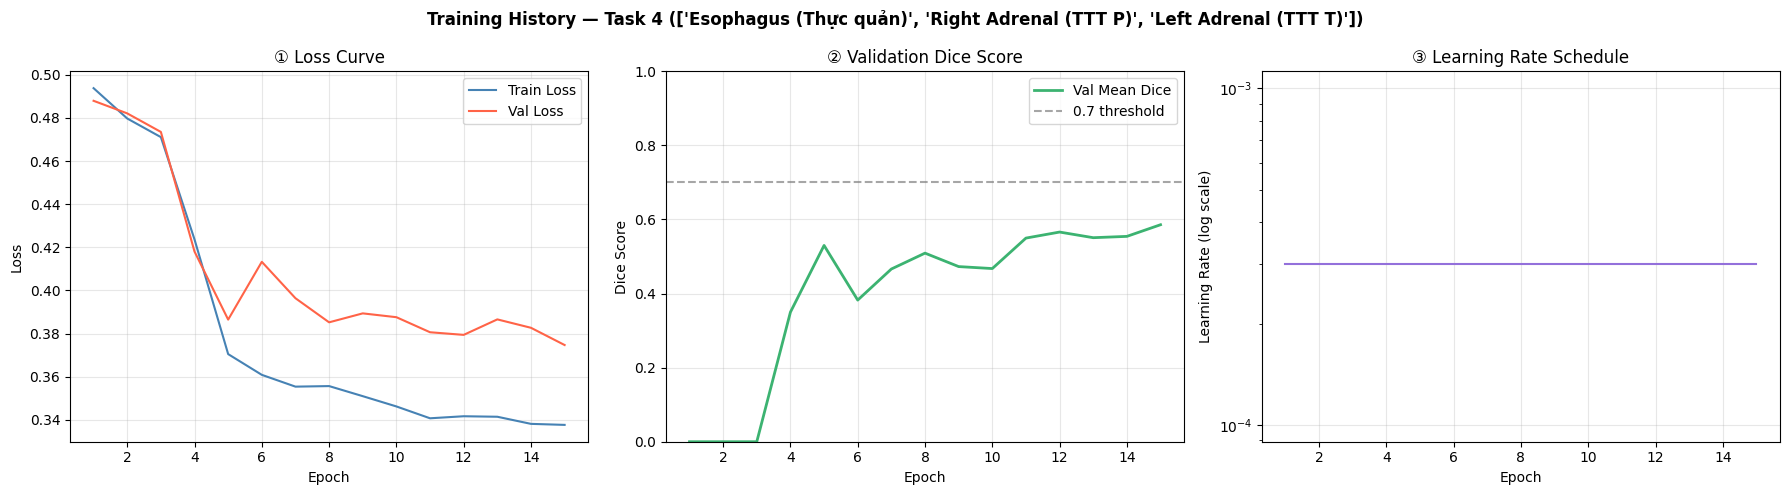

✅ Training curve saved: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/task4_training_curve.png
   Best Val Dice: 0.5858


In [ ]:
# ============================================================
# Vẽ Training Curves sau khi training hoàn tất
# ============================================================
history = trainer.history
epochs  = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Training History — Task {CURRENT_TASK} '
    f'({[ORGAN_NAMES[o] for o in TASK_ORGANS[CURRENT_TASK]]})',
    fontsize=12, fontweight='bold'
)

# Loss curve
axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("① Loss Curve")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Dice curve
axes[1].plot(epochs, history["val_dice"], label="Val Mean Dice",
             color="mediumseagreen", linewidth=2)
axes[1].axhline(0.7, color='gray', linestyle='--', alpha=0.7, label="0.7 threshold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice Score")
axes[1].set_title("② Validation Dice Score")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# LR curve
axes[2].semilogy(epochs, history["lr"], color="mediumpurple")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate (log scale)")
axes[2].set_title("③ Learning Rate Schedule")
axes[2].grid(alpha=0.3)

plt.tight_layout()
fig_path = f"{LOG_DIR}/task{CURRENT_TASK}_training_curve.png"
plt.savefig(fig_path, dpi=100)
plt.show()
print(f"✅ Training curve saved: {fig_path}")
print(f"   Best Val Dice: {trainer.best_val_dice:.4f}")

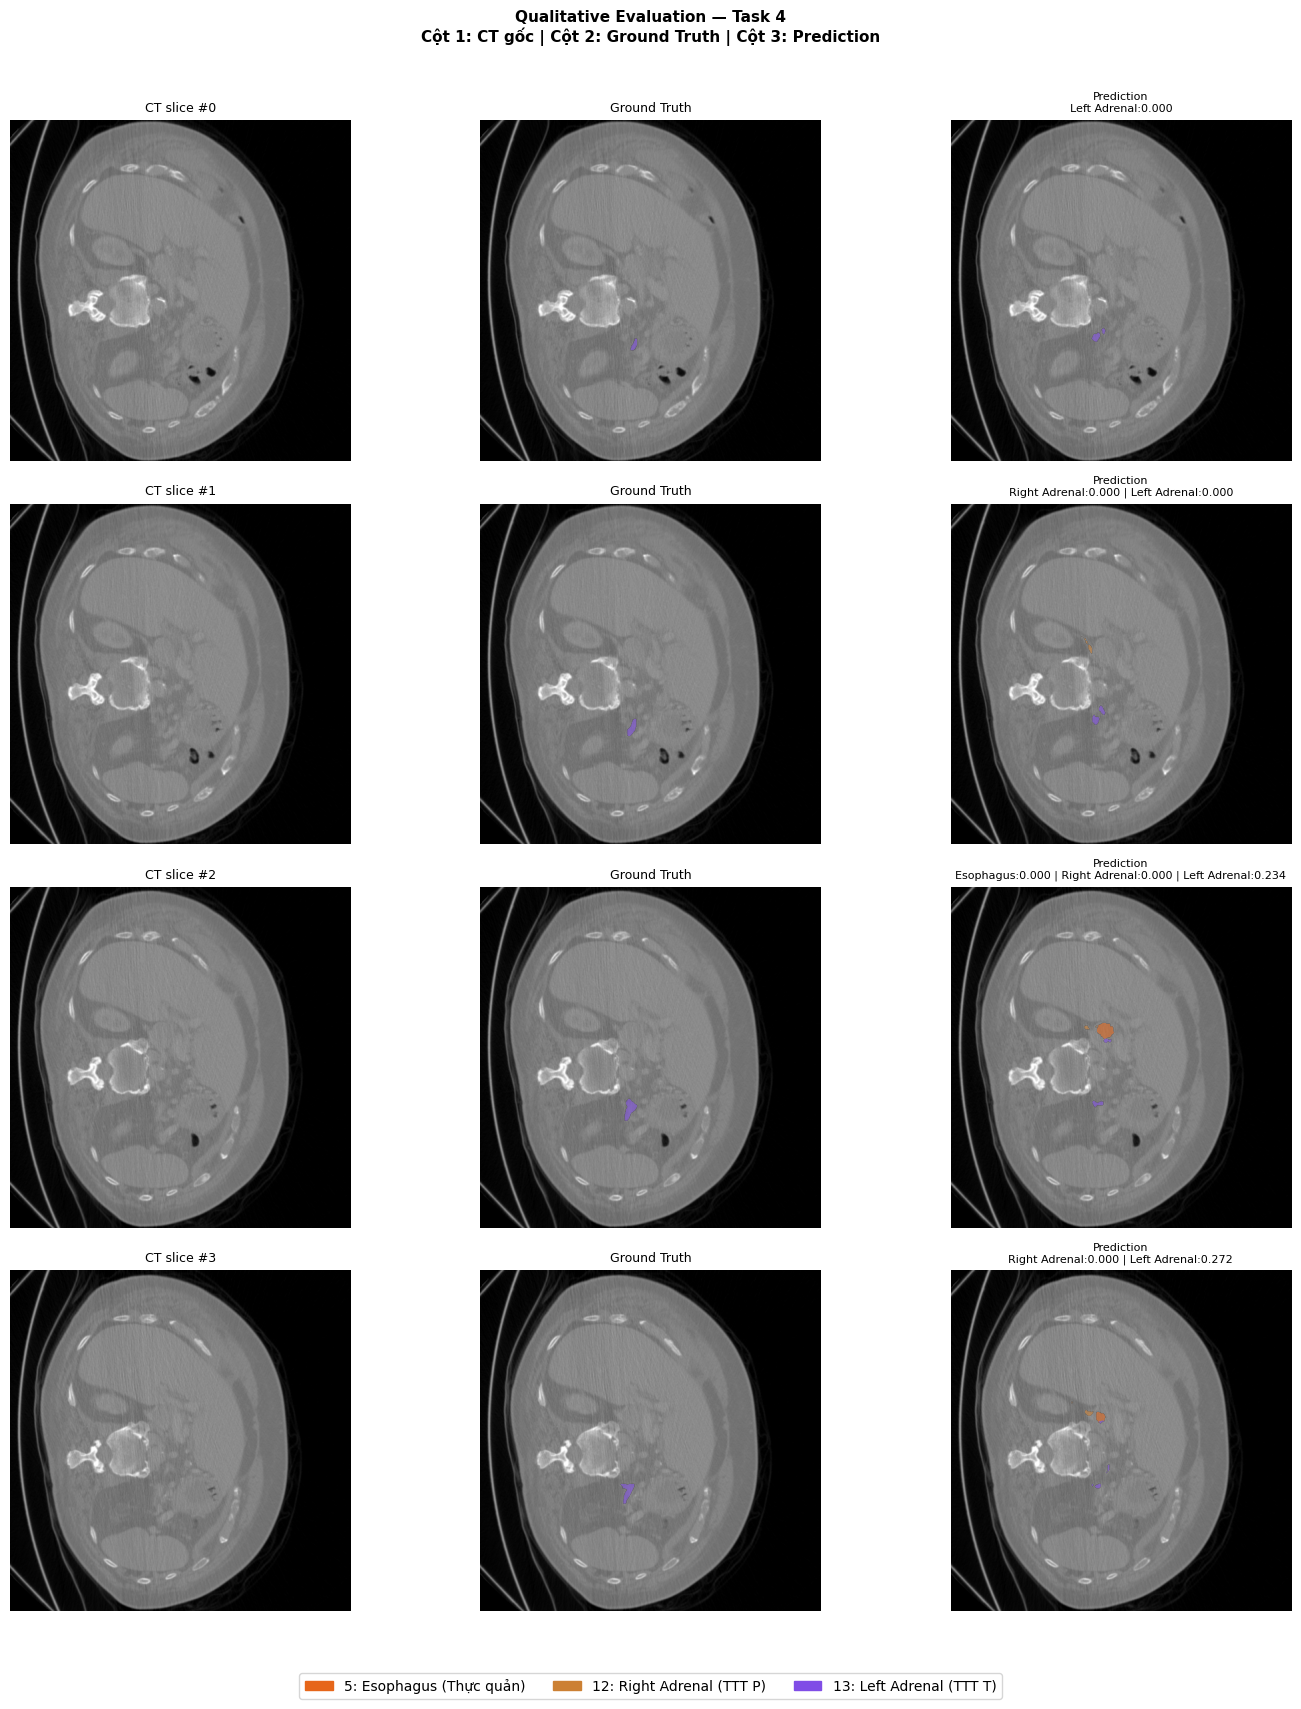

✅ Saved: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/task4_qualitative_eval.png


In [ ]:
# ============================================================
# Đánh giá định tính — Xem prediction trên một số slice
# ============================================================
model.eval()

# Lấy 4 batch từ val_loader
ct_batch, mask_batch = next(iter(val_loader))
ct_batch   = ct_batch.to(DEVICE)
mask_batch = mask_batch.to(DEVICE)

with torch.no_grad():
    logits = model(ct_batch)                          # (B, 14, H, W)
    preds  = torch.argmax(logits, dim=1).cpu().numpy()  # (B, H, W)

ct_np   = ct_batch.cpu().numpy()[:, 0]   # (B, H, W)
mask_np = mask_batch.cpu().numpy()       # (B, H, W)

n_show = min(4, ct_np.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show))
fig.suptitle(f'Qualitative Evaluation — Task {CURRENT_TASK}\n'
             f'Cột 1: CT gốc | Cột 2: Ground Truth | Cột 3: Prediction',
             fontsize=11, fontweight='bold', y=1.01)

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    ct_i   = ct_np[i]
    gt_i   = mask_np[i].astype(float)
    pred_i = preds[i].astype(float)

    # Mask 255 → NaN để không hiển thị
    gt_i[gt_i   == 255] = np.nan
    pred_i[pred_i == 255] = np.nan  # prediction thường không có 255

    axes[i][0].imshow(ct_i, cmap='gray', origin='upper')
    axes[i][0].set_title(f'CT slice #{i}', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(ct_i, cmap='gray', origin='upper')
    gt_masked = np.ma.masked_invalid(gt_i)
    axes[i][1].imshow(gt_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13,
                      alpha=0.7, origin='upper')
    axes[i][1].set_title('Ground Truth', fontsize=9)
    axes[i][1].axis('off')

    axes[i][2].imshow(ct_i, cmap='gray', origin='upper')
    pred_masked = np.ma.masked_where(pred_i == 0, pred_i)  # ẩn background
    axes[i][2].imshow(pred_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13,
                      alpha=0.7, origin='upper')

    # Tính dice cho slice này
    pred_tensor = torch.tensor(preds[i:i+1])
    gt_tensor   = torch.tensor(mask_np[i:i+1].astype(np.int64))
    slice_dice  = compute_dice_per_organ(
        logits[i:i+1].cpu(), gt_tensor, TASK_ORGANS[CURRENT_TASK]
    )
    dice_str = " | ".join(
        [f"{ORGAN_NAMES[o].split('(')[0].strip()}:{v:.3f}"
         for o, v in slice_dice.items() if not np.isnan(v)]
    )
    axes[i][2].set_title(f'Prediction\n{dice_str}', fontsize=8)
    axes[i][2].axis('off')

# Legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=ORGAN_COLORS[o][:3], label=f"{o}: {ORGAN_NAMES[o]}")
           for o in TASK_ORGANS[CURRENT_TASK]]
fig.legend(handles=patches, loc='lower center', ncol=len(TASK_ORGANS[CURRENT_TASK]),
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
eval_path = f"{LOG_DIR}/task{CURRENT_TASK}_qualitative_eval.png"
plt.savefig(eval_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {eval_path}")

📂 Loaded: img0007_slice_0124.npy  shape=(512, 512)


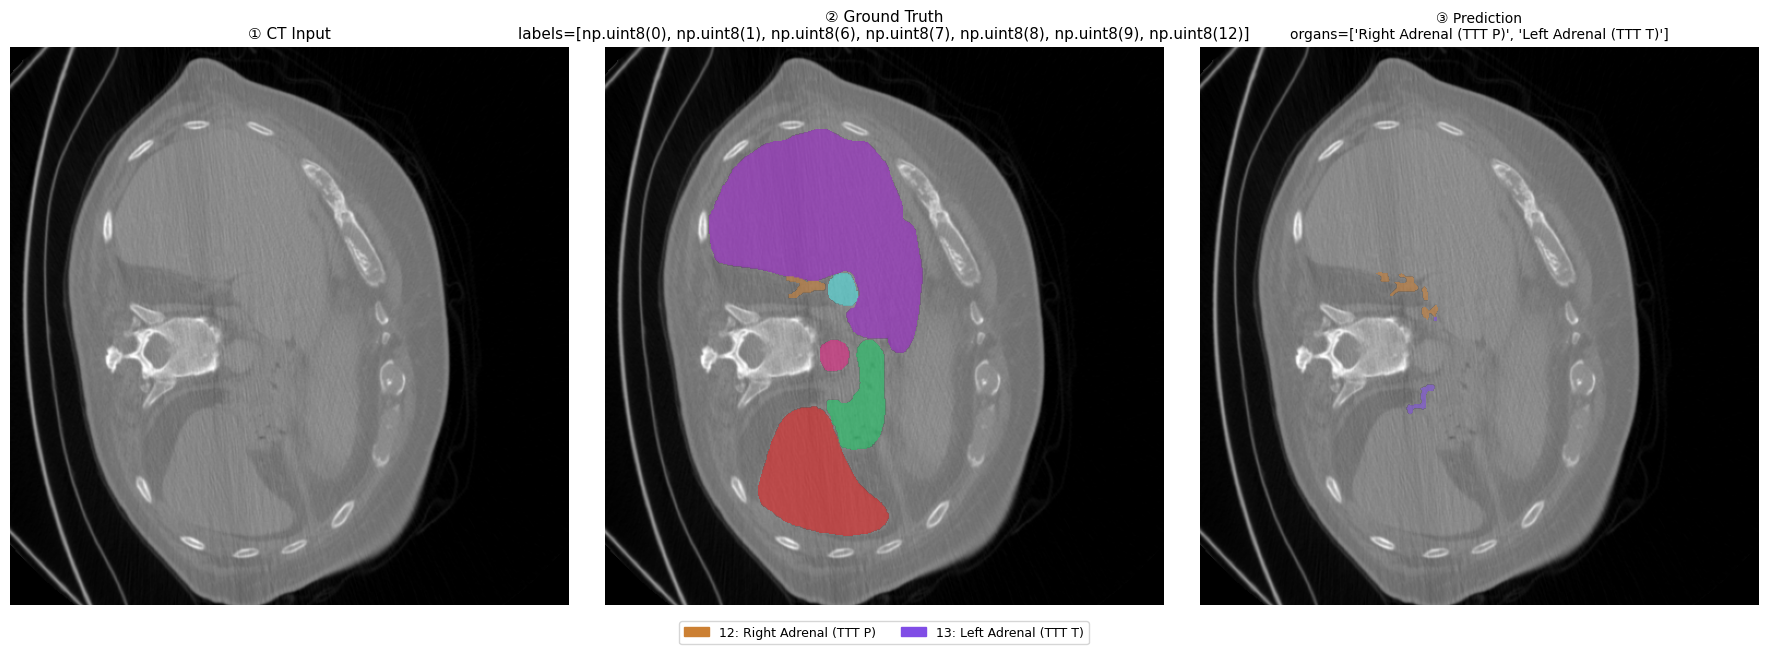


📊 Dice Score:
   Esophagus (Thực quản)         : N/A
   Right Adrenal (TTT P)         : 0.5263
   Left Adrenal (TTT T)          : 0.0000


In [ ]:
# ============================================================
# Test prediction trên 1 ảnh bất kỳ
# ============================================================
TEST_IMAGE = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/data/processed/images/img0007_slice_0124.npy"
TEST_MASK  = TEST_IMAGE.replace("/images/", "/masks/")  # tự tìm mask tương ứng

# Load ảnh
ct = np.load(TEST_IMAGE)  # (512, 512) float32
print(f"📂 Loaded: {os.path.basename(TEST_IMAGE)}  shape={ct.shape}")

# Predict
model.eval()
with torch.no_grad():
    ct_tensor = torch.from_numpy(ct).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1,1,H,W)
    logits    = model(ct_tensor)                                            # (1,14,H,W)
    pred      = torch.argmax(logits, dim=1).squeeze().cpu().numpy()         # (H,W)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ① CT gốc
axes[0].imshow(ct, cmap='gray', origin='upper')
axes[0].set_title('① CT Input', fontsize=11)
axes[0].axis('off')

# ② Ground Truth (nếu có mask)
if os.path.exists(TEST_MASK):
    mask = np.load(TEST_MASK)
    gt_masked = np.ma.masked_where(mask == 0, mask)
    axes[1].imshow(ct, cmap='gray', origin='upper')
    axes[1].imshow(gt_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')
    axes[1].set_title(f'② Ground Truth\nlabels={list(np.unique(mask))}', fontsize=11)
else:
    axes[1].imshow(ct, cmap='gray', origin='upper')
    axes[1].set_title('② No mask available', fontsize=11)
axes[1].axis('off')

# ③ Prediction
pred_masked = np.ma.masked_where(pred == 0, pred)
axes[2].imshow(ct, cmap='gray', origin='upper')
axes[2].imshow(pred_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')
pred_organs = [int(o) for o in np.unique(pred) if o > 0]
axes[2].set_title(f'③ Prediction\norgans={[ORGAN_NAMES.get(o,"?") for o in pred_organs]}', fontsize=10)
axes[2].axis('off')

# Legend
# Only create legend if there are predicted organs
if pred_organs:
    patches = [mpatches.Patch(color=ORGAN_COLORS[o][:3], label=f"{o}: {ORGAN_NAMES[o]}")
               for o in pred_organs]
    fig.legend(handles=patches, loc='lower center', ncol=len(pred_organs),
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# In Dice nếu có mask
if os.path.exists(TEST_MASK):
    print("\n📊 Dice Score:")
    # Iterate over organs relevant to the CURRENT_TASK
    for o in TASK_ORGANS[CURRENT_TASK]:
        p = (pred == o); t = (mask == o)
        inter = (p & t).sum(); total = p.sum() + t.sum()
        d = 2 * inter / total if total > 0 else float('nan')
        print(f"   {ORGAN_NAMES[o]:30s}: {d:.4f}" if not np.isnan(d) else f"   {ORGAN_NAMES[o]:30s}: N/A")

   New organs (Task 4): ['Esophagus (Thực quản)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']
   Old organs (Tasks trước): ['Liver (Gan)', 'Stomach (Dạ dày)', 'Spleen (Lách)', 'Right Kidney (Thận P)', 'Left Kidney (Thận T)', 'Aorta (ĐM chủ)', 'Gallbladder (Túi mật)', 'IVC (TM chủ dưới)', 'Portal Vein (TM cửa)', 'Pancreas (Tụy)']

📂 Loaded: img0007_slice_0084.npy  shape=(512, 512)


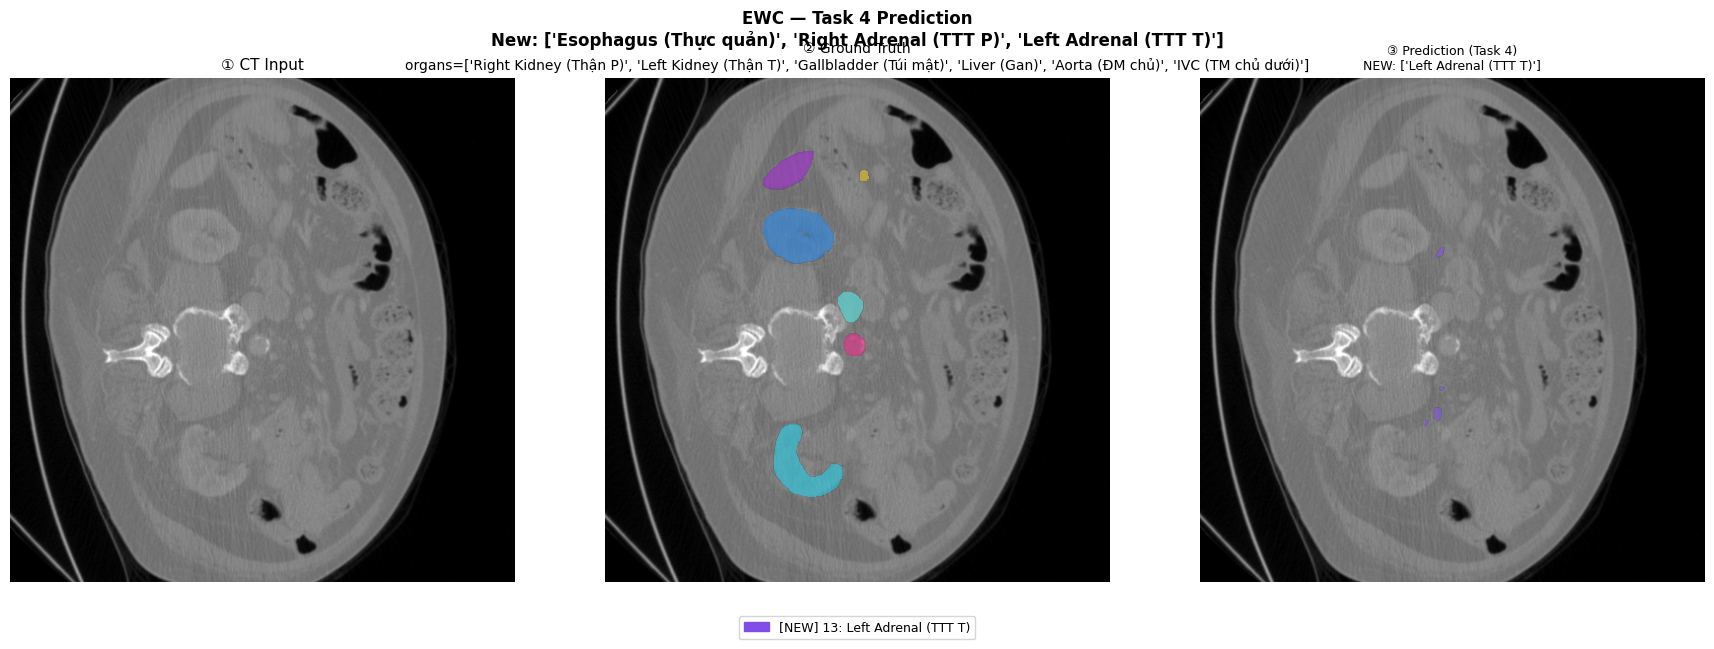


📊 Dice Score — Task 4 (evaluating ALL 13 learned organs):

  🆕 NEW organs (Task 4):
     Esophagus (Thực quản)         : N/A
     Right Adrenal (TTT P)         : N/A
     Left Adrenal (TTT T)          : 0.0000

  📦 OLD organs (Tasks 1→3):
     Liver (Gan)                   : 0.0000  ⚠️ forgetting!
     Stomach (Dạ dày)              : N/A
     Spleen (Lách)                 : N/A
     Right Kidney (Thận P)         : 0.0000  ⚠️ forgetting!
     Left Kidney (Thận T)          : 0.0000  ⚠️ forgetting!
     Aorta (ĐM chủ)                : 0.0000  ⚠️ forgetting!
     Gallbladder (Túi mật)         : 0.0000  ⚠️ forgetting!
     IVC (TM chủ dưới)             : 0.0000  ⚠️ forgetting!
     Portal Vein (TM cửa)          : N/A
     Pancreas (Tụy)                : N/A


In [ ]:
# Tất cả organs đã học tới task hiện tại
all_learned = ALL_PAST_ORGANS[CURRENT_TASK]
new_organs  = TASK_ORGANS[CURRENT_TASK]
old_organs  = [o for o in all_learned if o not in new_organs]

print(f"   New organs (Task {CURRENT_TASK}): {[ORGAN_NAMES[o] for o in new_organs]}")
if old_organs:
    print(f"   Old organs (Tasks trước): {[ORGAN_NAMES[o] for o in old_organs]}")

# ---- Ảnh test ----
TEST_IMAGE = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/data/processed/images/img0007_slice_0084.npy"
TEST_MASK  = TEST_IMAGE.replace("/images/", "/masks/")

# Load ảnh
ct = np.load(TEST_IMAGE)  # (512, 512) float32
print(f"\n📂 Loaded: {os.path.basename(TEST_IMAGE)}  shape={ct.shape}")

# Predict
with torch.no_grad():
    ct_tensor = torch.from_numpy(ct).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1,1,H,W)
    logits    = model(ct_tensor)                                            # (1,14,H,W)
    pred      = torch.argmax(logits, dim=1).squeeze().cpu().numpy()         # (H,W)

# ============================================================
# Visualize — hiển thị cả OLD organs và NEW organs
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'EWC — Task {CURRENT_TASK} Prediction\n'
    f'New: {[ORGAN_NAMES[o] for o in new_organs]}',
    fontsize=12, fontweight='bold'
)

# ① CT gốc
axes[0].imshow(ct, cmap='gray', origin='upper')
axes[0].set_title('① CT Input', fontsize=11)
axes[0].axis('off')

# ② Ground Truth (tất cả organs đã học)
if os.path.exists(TEST_MASK):
    mask = np.load(TEST_MASK)
    # Chỉ hiển thị organs đã học (all_learned)
    gt_display = mask.copy().astype(float)
    gt_display[~np.isin(mask, [0] + all_learned)] = np.nan
    gt_masked = np.ma.masked_where((gt_display == 0) | np.isnan(gt_display), gt_display)
    axes[1].imshow(ct, cmap='gray', origin='upper')
    axes[1].imshow(gt_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')
    gt_organs_present = [int(o) for o in np.unique(mask) if o in all_learned]
    axes[1].set_title(
        f'② Ground Truth\n'
        f'organs={[ORGAN_NAMES.get(o,"?") for o in gt_organs_present]}',
        fontsize=10
    )
else:
    axes[1].imshow(ct, cmap='gray', origin='upper')
    axes[1].set_title('② No mask available', fontsize=11)
axes[1].axis('off')

# ③ Prediction (tất cả organs đã học)
pred_masked = np.ma.masked_where(pred == 0, pred)
axes[2].imshow(ct, cmap='gray', origin='upper')
axes[2].imshow(pred_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')
pred_organs = [int(o) for o in np.unique(pred) if o > 0]
# Phân loại predicted organs thành old/new
pred_new = [o for o in pred_organs if o in new_organs]
pred_old = [o for o in pred_organs if o in old_organs]
title_parts = [f'③ Prediction (Task {CURRENT_TASK})']
if pred_new:
    title_parts.append(f'NEW: {[ORGAN_NAMES.get(o,"?") for o in pred_new]}')
if pred_old:
    title_parts.append(f'OLD: {[ORGAN_NAMES.get(o,"?") for o in pred_old]}')
axes[2].set_title('\n'.join(title_parts), fontsize=9)
axes[2].axis('off')

# Legend — phân biệt OLD (■) vs NEW (★) organs
if pred_organs:
    patches = []
    for o in pred_organs:
        label_prefix = "[NEW]" if o in new_organs else "[OLD]"
        patches.append(
            mpatches.Patch(
                color=ORGAN_COLORS[o][:3],
                label=f"{label_prefix} {o}: {ORGAN_NAMES[o]}"
            )
        )
    fig.legend(
        handles=patches, loc='lower center',
        ncol=min(len(patches), 4),
        fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08)
    )

plt.tight_layout()
plt.show()

# ============================================================
# Dice Score — đánh giá trên TẤT CẢ organs đã học
# ============================================================
if os.path.exists(TEST_MASK):
    print(f"\n📊 Dice Score — Task {CURRENT_TASK} (evaluating ALL {len(all_learned)} learned organs):")

    # NEW organs (task hiện tại)
    print(f"\n  🆕 NEW organs (Task {CURRENT_TASK}):")
    for o in new_organs:
        p = (pred == o); t = (mask == o)
        inter = (p & t).sum(); total = p.sum() + t.sum()
        d = 2 * inter / total if total > 0 else float('nan')
        if not np.isnan(d):
            print(f"     {ORGAN_NAMES[o]:30s}: {d:.4f}")
        else:
            print(f"     {ORGAN_NAMES[o]:30s}: N/A")

    # OLD organs (tasks trước)
    if old_organs:
        print(f"\n  📦 OLD organs (Tasks 1→{CURRENT_TASK-1}):")
        for o in old_organs:
            p = (pred == o); t = (mask == o)
            inter = (p & t).sum(); total = p.sum() + t.sum()
            d = 2 * inter / total if total > 0 else float('nan')
            if not np.isnan(d):
                status = "✅" if d >= 0.5 else "⚠️ forgetting!"
                print(f"     {ORGAN_NAMES[o]:30s}: {d:.4f}  {status}")
            else:
                print(f"     {ORGAN_NAMES[o]:30s}: N/A")


In [ ]:
import json
R = {}
for i in range(1, 5):
    path = f"{LOG_DIR}/task{i}_cil_results.json"
    with open(path) as f:
        data = json.load(f)
    R[i] = {int(k.split('][')[1].rstrip(']')): v
            for k, v in data["performance_matrix_row"].items()}

# In full matrix
print("         Task1  Task2  Task3  Task4")
for i in range(1, 5):
    row = f"Task {i}  "
    for j in range(1, 5):
        v = R.get(i, {}).get(j)
        row += f"{v:.4f} " if v is not None else "  ---  "
    print(row)

         Task1  Task2  Task3  Task4
Task 1  0.7706   ---    ---    ---  
Task 2  0.0000 0.7272   ---    ---  
Task 3  0.0000 0.0000 0.3265   ---  
Task 4  0.0000 0.0000 0.0000 0.4004 
